# **UCI-HAR - SEnet (PyTorch)**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# PyTorch 관련 라이브러리 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
# GPU 가속 공식 설정 (Colab 환경 대응)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data load

In [3]:
TRAIN = "train/"
TEST = "test/"

# 구글 드라이브 연동 경로 유지
DATASET_PATH = "/content/drive/MyDrive/AI_Study/UCI_HAR_Dataset/"

In [4]:
# UCI HAR 데이터셋 상수 설정
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [5]:
# 1. X 데이터 로드 함수 수정 (파이토치 1D CNN 차원에 맞춤)
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')
                row_clean = row_clean.strip()
                serie = row_clean.split(' ')
                serie_array = np.array(serie, dtype=np.float32)
                series_list.append(serie_array)

        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)

    # [수정] 텐서플로우용: (1, 2, 0) -> (샘플 수, 타임스텝 수, 특성 수)
    # [수정] 파이토치용:   (1, 0, 2) -> (샘플 수, 특성 수, 타임스텝 수)
    # 파이토치 nn.Conv1d는 채널(특성 수)이 중간에 와야 한다.
    return np.transpose(X_signals, (1, 0, 2))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("=== X Data Shape (PyTorch Style) ===")
print("X_train shape (Batch, Channels, Timesteps):", X_train.shape) # (7352, 9, 128)
print("X_test shape (Batch, Channels, Timesteps):", X_test.shape)   # (2947, 9, 128)

=== X Data Shape (PyTorch Style) ===
X_train shape (Batch, Channels, Timesteps): (7352, 9, 128)
X_test shape (Batch, Channels, Timesteps): (2947, 9, 128)


In [6]:
# 2. y 데이터 로드 함수 (정수형 레이블 그대로 유지)
def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 파이토치 CrossEntropyLoss는 target으로 Long(int64) 타입을 요구하므로 np.int64로 설정
    return np.array(labels, dtype=np.int64) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("\n=== y Data Shape ===")
print("y_train shape (정수 인덱스):", y_train.shape) # (7352,)
print("y_test shape (정수 인덱스):", y_test.shape)   # (2947,)
print("y_train 앞 5개 샘플:", y_train[:5])


=== y Data Shape ===
y_train shape (정수 인덱스): (7352,)
y_test shape (정수 인덱스): (2947,)
y_train 앞 5개 샘플: [4 4 4 4 4]


# Model building

In [7]:
# --- SE (Squeeze-and-Excitation) 블록 정의 ---
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction_ratio=16):
        super(SEBlock1D, self).__init__()
        # 1. Squeeze: 전역 정보 압축을 위한 글로벌 에버리지 풀링
        self.squeeze = nn.AdaptiveAvgPool1d(1)

        # 2. Excitation: 채널 간 상호작용 및 중요도 계산
        # 파이토치는 Dense 대신 nn.Linear를 사용하며 (입력 채널, 출력 채널) 순서
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(channels // reduction_ratio, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x shape: (Batch, Channels, Length)
        batch, channels, _ = x.size()

        # Squeeze 수행 -> (Batch, Channels, 1) -> (Batch, Channels)
        s = self.squeeze(x).view(batch, channels)

        # Excitation 수행 -> (Batch, Channels) -> (Batch, Channels, 1)로 차원 복원
        e = self.excitation(s).view(batch, channels, 1)

        # 3. Scale: 원본 입력 텐서와 가중치를 곱해줌 (브로드캐스팅 적용)
        return x * e

In [8]:
# --- 전체 SENet 모델 빌딩 ---
class SENet1D(nn.Module):
    def __init__(self, in_channels=9, num_classes=6):
        super(SENet1D, self).__init__()

        # 첫 번째 특징 추출 (Conv -> BN -> ReLU -> SE)
        self.conv1 = nn.Conv1d(in_channels, 128, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(128)
        self.relu1 = nn.ReLU()
        self.se1 = SEBlock1D(128, reduction_ratio=16)

        # 두 번째 특징 추출 (+ MaxPooling, Dropout)
        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu2 = nn.ReLU()
        self.se2 = SEBlock1D(256, reduction_ratio=16)
        self.pool2 = nn.MaxPool1d(2)
        self.drop2 = nn.Dropout(0.3)

        # 세 번째 특징 추출
        self.conv3 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(256)
        self.relu3 = nn.ReLU()
        self.se3 = SEBlock1D(256, reduction_ratio=16)

        # 네 번째 특징 추출 (+ MaxPooling)
        self.conv4 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(256)
        self.relu4 = nn.ReLU()
        self.se4 = SEBlock1D(256, reduction_ratio=16)
        self.pool4 = nn.MaxPool1d(2)

        # 차원 축소 및 분류층
        self.global_pool = nn.AdaptiveAvgPool1d(1) # GlobalAveragePooling1D 에서 변환

        self.fc = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes) # 최종 출력 (Softmax는 Loss에서 처리하므로 제외)
        )

    def forward(self, x):
        # x shape: (Batch, Channels, Length)
        x = self.se1(self.relu1(self.bn1(self.conv1(x))))

        x = self.se2(self.relu2(self.bn2(self.conv2(x))))
        x = self.drop2(self.pool2(x))

        x = self.se3(self.relu3(self.bn3(self.conv3(x))))

        x = self.se4(self.relu4(self.bn4(self.conv4(x))))
        x = self.pool4(x)

        # Global Average Pooling 후 1차원으로 평탄화
        x = self.global_pool(x).squeeze(-1) # (Batch, 256)

        # Fully Connected Layer
        output = self.fc(x)
        return output

# --- 모델 생성 및 확인 ---
# 디바이스 변수(cuda 혹은 cpu)는 첫 번째 문단에서 정의한 것을 공유함.
model = SENet1D(in_channels=9, num_classes=6).to(device)

# 케라스의 model.summary()와 유사한 출력을 위해 구조 프린트
print(model)

SENet1D(
  (conv1): Conv1d(9, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (se1): SEBlock1D(
    (squeeze): AdaptiveAvgPool1d(output_size=1)
    (excitation): Sequential(
      (0): Linear(in_features=128, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=128, bias=True)
      (3): Sigmoid()
    )
  )
  (conv2): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (se2): SEBlock1D(
    (squeeze): AdaptiveAvgPool1d(output_size=1)
    (excitation): Sequential(
      (0): Linear(in_features=256, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=256, bias=True)
      (3): Sigmoid()
    )
  )
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

# Loss + Callback

In [9]:
import copy
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 1. 손실함수 및 옵티마이저 정의
criterion = nn.CrossEntropyLoss()                     # categorical_crossentropy + Softmax 역할
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 기본 lr=0.001 시작

# 2. ReduceLROnPlateau 스케줄러 정의 (Keras와 동일한 세팅)
lr_scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',          # val_loss 최소화를 목표로 설정
    factor=0.2,          # Keras의 factor=0.2
    patience=8,          # Keras의 patience=8
    min_lr=0.00001,      # Keras의 min_lr
)

# 3. ModelCheckpoint 및 EarlyStopping을 수동 제어하기 위한 기준 변수 설정
early_stopping_patience = 25
patience_counter = 0

best_val_acc = 0.0                                 # Keras의 mode='max' (val_categorical_accuracy 기준)
best_model_wts = copy.deepcopy(model.state_dict()) # restore_best_weights=True를 위한 가중치 저장소

checkpoint_path = "UCI_HAR_SEnet_best.pt"          # .keras 대신 파이토치는 보통 .pt 나 .pth 사용

# Model train

In [10]:
import time
from torch.utils.data import TensorDataset, random_split

# --- 1. Dataset 및 DataLoader 준비 (Keras의 validation_split=0.2 및 batch_size=16 대응) ---
# 넘파이 배열을 파이토치 텐서로 변환
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.long)  # 원-핫 인코딩 대신 정수형 레이블 사용

# 전체 데이터셋 생성
full_dataset = TensorDataset(X_tensor, y_tensor)

# 80% 학습, 20% 검증 데이터로 분할
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoader 생성 (batch_size=16)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [11]:
# --- 2. History 저장을 위한 딕셔너리 정의 ---
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

In [12]:
# --- 3. 학습 및 검증 루프 실행 (epochs=100) ---
epochs = 100

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # [Train Phase]
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train_samples = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # 그래디언트 초기화
        optimizer.zero_grad()

        # 순전파 (Forward)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # 역전파 및 가중치 업데이트 (Backward)
        loss.backward()
        optimizer.step()

        # 통계 계산
        train_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == batch_y).sum().item()
        total_train_samples += batch_X.size(0)

    epoch_train_loss = train_loss / total_train_samples
    epoch_train_acc = train_correct / total_train_samples

    # [Validation Phase]
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val_samples = 0

    with torch.no_grad(): # 검증 시에는 그래디언트 계산 제외 (메모리 절약)
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == batch_y).sum().item()
            total_val_samples += batch_X.size(0)

    epoch_val_loss = val_loss / total_val_samples
    epoch_val_acc = val_correct / total_val_samples

    # History 기록
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    # 에폭 결과 출력 (Keras의 verbose=1 스타일)
    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}/{epochs} - {epoch_time:.1f}s - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f} - lr: {current_lr:.6f}")

    # --- 4. Callbacks 수동 연동 단계 ---
    # (1) ReduceLROnPlateau 스케줄러 업데이트
    lr_scheduler.step(epoch_val_loss)

    # (2) ModelCheckpoint & EarlyStopping 체크
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict()) # 최적 가중치 메모리 복사
        torch.save(model.state_dict(), checkpoint_path)    # 파일 저장 (.pt)
        print(f"Epoch {epoch}: val_categorical_accuracy improved to {epoch_val_acc:.5f}, saving model to {checkpoint_path}")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print(f"Early stopping triggered. Restoring model weights from the end of the best epoch.")
        model.load_state_dict(best_model_wts) # 최적 가중치로 복원
        break

Epoch 1/100 - 4.3s - loss: 0.3385 - accuracy: 0.8774 - val_loss: 0.1268 - val_accuracy: 0.9456 - lr: 0.001000
Epoch 1: val_categorical_accuracy improved to 0.94562, saving model to UCI_HAR_SEnet_best.pt
Epoch 2/100 - 2.7s - loss: 0.2075 - accuracy: 0.9208 - val_loss: 0.1232 - val_accuracy: 0.9531 - lr: 0.001000
Epoch 2: val_categorical_accuracy improved to 0.95309, saving model to UCI_HAR_SEnet_best.pt
Epoch 3/100 - 3.2s - loss: 0.1803 - accuracy: 0.9284 - val_loss: 0.1226 - val_accuracy: 0.9483 - lr: 0.001000
Epoch 4/100 - 3.0s - loss: 0.1686 - accuracy: 0.9313 - val_loss: 0.1164 - val_accuracy: 0.9592 - lr: 0.001000
Epoch 4: val_categorical_accuracy improved to 0.95921, saving model to UCI_HAR_SEnet_best.pt
Epoch 5/100 - 2.7s - loss: 0.1495 - accuracy: 0.9427 - val_loss: 0.1042 - val_accuracy: 0.9545 - lr: 0.001000
Epoch 6/100 - 2.7s - loss: 0.1521 - accuracy: 0.9393 - val_loss: 0.1198 - val_accuracy: 0.9449 - lr: 0.001000
Epoch 7/100 - 2.8s - loss: 0.1541 - accuracy: 0.9390 - val_lo

# Evaluation

Best 기록 확인

In [13]:
# --- 1. 가중치를 불러올 빈 모델 객체 생성 ---
# 기존에 정의한 SENet1D 구조와 똑같은 빈 껍데기를 만드는 것
best_model = SENet1D(in_channels=9, num_classes=6).to(device)

# 가중치 파일(.pt) 로드
# 이전 콜백 단계에서 지정한 checkpoint_path = "UCI_HAR_SEnet_best.pt" 를 사용
best_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
print(f"Successfully loaded best model weights from {checkpoint_path}")


# --- 2. 데이터 평가를 위한 수동 함수 정의 ---
def evaluate_pytorch_model(model, X_data, y_data, batch_size=16):
    # 케라스의 evaluate(verbose=0)처럼 배치를 돌며 손실과 정확도를 누적 계산
    model.eval() # 평가 모드 활성화 (Dropout, BatchNorm 동결)

    # 평가용 DataLoader 구성
    eval_tensor_X = torch.tensor(X_data, dtype=torch.float32)
    eval_tensor_y = torch.tensor(y_data, dtype=torch.long)
    eval_dataset = TensorDataset(eval_tensor_X, eval_tensor_y)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad(): # 평가 단계이므로 그래디언트 계산 제외
        for batch_X, batch_y in eval_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total_samples += batch_X.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = correct / total_samples
    return avg_loss, avg_acc


# --- 3. Training & Test 데이터셋 평가 및 출력 ---
# X_train전체 데이터에 대해 평가 (Keras의 validation_split 전 원본 데이터 기준)
train_loss, train_acc = evaluate_pytorch_model(best_model, X_train, y_train)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

# X_test 데이터셋 평가
test_loss, test_acc = evaluate_pytorch_model(best_model, X_test, y_test)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Successfully loaded best model weights from UCI_HAR_SEnet_best.pt
Training accuracy: 98.87%
Training loss: 0.0318
Test accuracy: 95.59%
Test loss: 0.2059


Classification Report

In [14]:
import torch.nn.functional as F

# --- 1. 모델 예측 (Keras의 model.predict 부분) ---
best_model.eval() # 평가 모드 활성화

# 예측용 DataLoader 구성 (X_test 전체를 안정적으로 처리하기 위해 배치 단위 구동)
test_tensor_X = torch.tensor(X_test, dtype=torch.float32)
test_dataset = TensorDataset(test_tensor_X)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

y_pred_list = []

with torch.no_grad():
    for batch_X in test_loader:
        batch_X = batch_X[0].to(device) # TensorDataset은 튜플 형태로 반환하므로 꺼내옴

        # 순전파로 로짓(Logit) 계산
        outputs = best_model(batch_X)

        # 로짓을 소프트맥스를 통해 확률값(0~1 사이)으로 변환 (Keras의 predict 결과와 대응되는 부분)
        probabilities = F.softmax(outputs, dim=1)

        # 가장 높은 확률을 가진 클래스 추출
        _, predicted = torch.max(probabilities, 1)

        # CPU로 넘긴 뒤 리스트에 저장
        y_pred_list.extend(predicted.cpu().numpy())

# 넘파이 배열로 최종 변환
y_pred = np.array(y_pred_list)


# --- 2. 분류 리포트 출력 ---
print("\nClassification Report:")
# y_test는 이미 정수형 레이블(0~5)이므로 그대로 사용
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9919    0.9960       496
           1     0.9934    0.9660    0.9795       471
           2     0.9567    1.0000    0.9779       420
           3     0.9461    0.8228    0.8802       491
           4     0.8656    0.9568    0.9089       532
           5     0.9890    1.0000    0.9944       537

    accuracy                         0.9559      2947
   macro avg     0.9585    0.9563    0.9562      2947
weighted avg     0.9575    0.9559    0.9555      2947



Loss / Accuracy 그래프

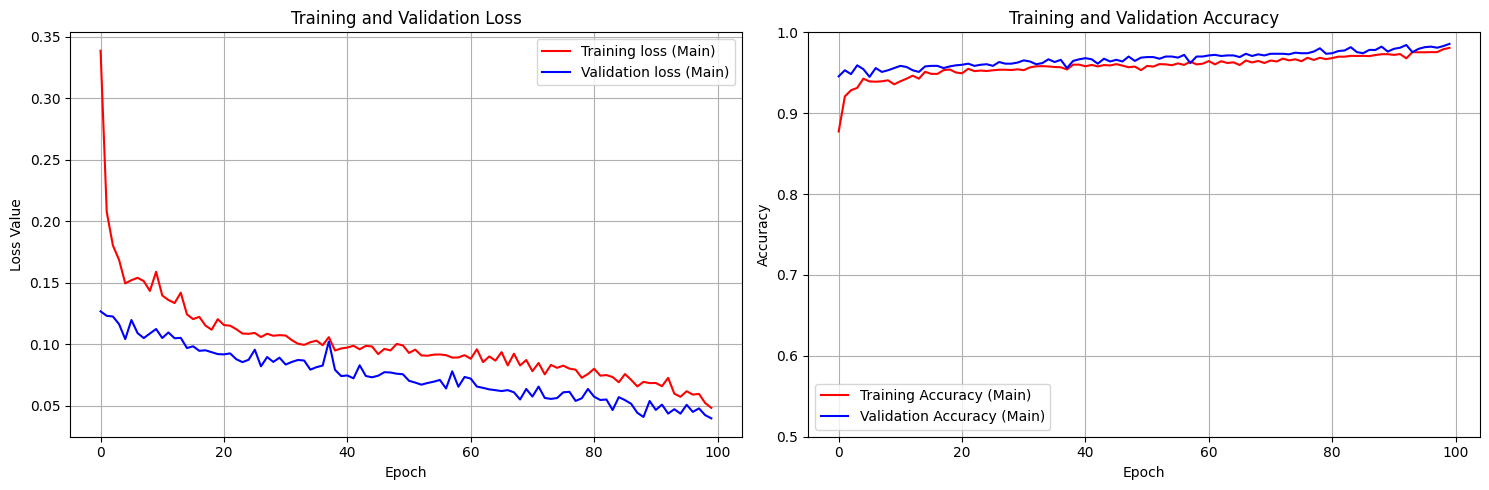

In [15]:
# --- 1. History 딕셔너리에서 학습 기록 데이터 추출 ---
# 파이토치 루프에서 직접 채워넣은 history 딕셔너리를 활용
train_loss = history['loss']
train_accuracy = history['accuracy']
val_loss = history['val_loss']
val_accuracy = history['val_accuracy']

# --- 2. Matplotlib을 이용한 시각화 그래프 그리기 ---
plt.figure(figsize=(15, 5))

# 2-1. Loss 그래프 (왼쪽)
plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss (Main)')
plt.plot(val_loss, 'b', label='Validation loss (Main)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

# 2-2. Accuracy 그래프 (오른쪽)
plt.subplot(1, 2, 2)
plt.ylim([0.5, 1.0]) # 데이터셋 특성에 맞춰 Y축 범위 지정
plt.plot(train_accuracy, 'r', label='Training Accuracy (Main)')
plt.plot(val_accuracy, 'b', label='Validation Accuracy (Main)')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()